# Homework 4 — U-Net Training

`smp.Unet(encoder_name='efficientnet-b0', encoder_weights='imagenet')` with
**BCE + Dice** loss. 30 epochs, save best by validation Dice.

In [1]:
import os, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}   smp: {smp.__version__}")
torch.manual_seed(0); np.random.seed(0); random.seed(0)

/home/vscode/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda   smp: 0.5.0


## 1. Dataset + augmentations

In [2]:
ROOT = "datasets/bbbc010_seg"
MEAN = [0.485, 0.456, 0.406]; STD = [0.229, 0.224, 0.225]

train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
eval_tf = A.Compose([A.Normalize(mean=MEAN, std=STD), ToTensorV2()])

class WormDataset(Dataset):
    def __init__(self, split, transform):
        self.img_dir  = os.path.join(ROOT, split, "images")
        self.mask_dir = os.path.join(ROOT, split, "masks")
        self.files = sorted(os.listdir(self.img_dir))
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        f = self.files[i]
        img  = np.array(Image.open(os.path.join(self.img_dir,  f)).convert("RGB"))
        mask = np.array(Image.open(os.path.join(self.mask_dir, f)).convert("L")) // 255
        out = self.transform(image=img, mask=mask)
        return out["image"], out["mask"].unsqueeze(0).float()

train_ds = WormDataset("train", train_tf)
val_ds   = WormDataset("test",  eval_tf)
print(f"train={len(train_ds)}  val={len(val_ds)}")

BATCH = 4
# num_workers=0 / pin_memory=False: the dev container /dev/shm is tiny and worker
# processes crash with a bus error otherwise (same fix I used in HW 3).
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=False, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)

train=80  val=20


## 2. Model + loss

In [3]:
model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

bce  = nn.BCEWithLogitsLoss()
dice = smp.losses.DiceLoss(mode="binary")
# combined loss: equal-weight mix of BCE and Dice
def loss_fn(logits, y): return 0.5 * bce(logits, y) + 0.5 * dice(logits, y)

@torch.no_grad()
def dice_iou(logits, y, thr=0.5):
    pred = (torch.sigmoid(logits) > thr).long()
    tp, fp, fn, tn = smp.metrics.get_stats(pred, y.long(), mode="binary")
    return (smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro").item(),
            smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item())

Params: 6.25 M


## 3. Training loop (30 epochs, save best by val Dice)

In [4]:
EPOCHS = 30
LR = 1e-4
CKPT = "checkpoints/unet_efficientnet-b0.pt"
os.makedirs(os.path.dirname(CKPT), exist_ok=True)

opt = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_losses = []
    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        opt.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward(); opt.step()
        tr_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.3f}")
    sched.step()

    model.eval()
    vl, vd, vi = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            vl.append(loss_fn(logits, y).item())
            d, i = dice_iou(logits, y); vd.append(d); vi.append(i)
    tr_mean = float(np.mean(tr_losses)); vl_mean = float(np.mean(vl))
    vd_mean = float(np.mean(vd));        vi_mean = float(np.mean(vi))
    history["train_loss"].append(tr_mean); history["val_loss"].append(vl_mean)
    history["val_dice"].append(vd_mean);   history["val_iou"].append(vi_mean)

    flag = ""
    if vd_mean > best:
        best = vd_mean
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_dice": vd_mean}, CKPT)
        flag = "  ★ new best"
    print(f"epoch {epoch:02d}  train={tr_mean:.3f}  val={vl_mean:.3f}  "
          f"dice={vd_mean:.3f}  iou={vi_mean:.3f}{flag}")

print(f"\nBest val Dice = {best:.4f}  →  {CKPT}")

epoch 1/30:   0%|          | 0/20 [00:00<?, ?it/s]

epoch 1/30:   0%|          | 0/20 [00:01<?, ?it/s, loss=0.943]

epoch 1/30:   5%|▌         | 1/20 [00:01<00:30,  1.61s/it, loss=0.943]

epoch 1/30:   5%|▌         | 1/20 [00:01<00:30,  1.61s/it, loss=0.931]

epoch 1/30:  10%|█         | 2/20 [00:01<00:13,  1.35it/s, loss=0.931]

...

epoch 30/30:  90%|█████████ | 18/20 [00:02<00:00,  8.03it/s, loss=0.355]

epoch 30/30:  95%|█████████▌| 19/20 [00:02<00:00,  8.10it/s, loss=0.355]

epoch 30/30:  95%|█████████▌| 19/20 [00:02<00:00,  8.10it/s, loss=0.339]

epoch 30/30: 100%|██████████| 20/20 [00:02<00:00,  8.22it/s, loss=0.339]

epoch 30  train=0.352  val=0.361  dice=0.860  iou=0.755  ★ new best

Best val Dice = 0.8600  →  checkpoints/unet_efficientnet-b0.pt


## 4. Training curves

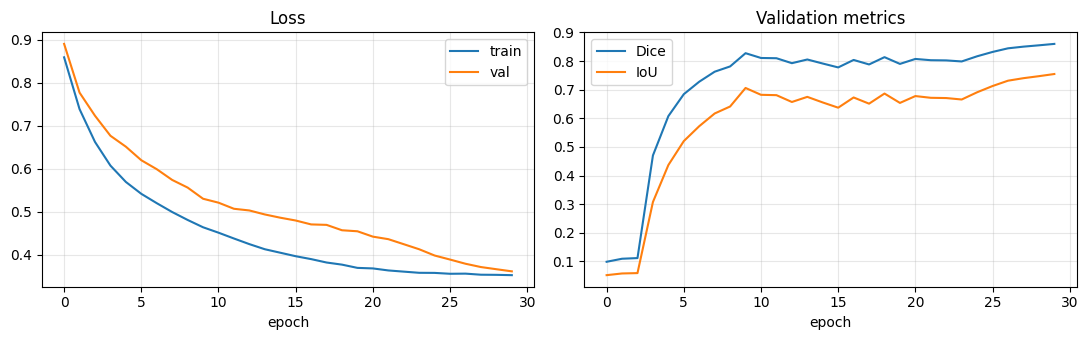

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history["val_dice"], label="Dice"); ax[1].plot(history["val_iou"], label="IoU")
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Conclusion

Best checkpoint saved. Move on to `02_Evaluation.ipynb`.